# ToF-SIMS mammary-tumour multi-ion signature — leakage-free, mouse-level analysis

Reproducibility notebook. Regenerates every reported statistic from the peak-area table.
The **experimental unit is the animal**; all preprocessing is refit inside cross-validation folds
(no leakage); performance carries bootstrap confidence intervals and animal-label permutation p-values.

**Headline results**
- Mammary tumour vs healthy: mouse-level AUC ≈ **0.99** (both PLS-DA and RF), permutation **P = 0.002** (BH 0.008); 98 differential ions.
- Fur: weak, model-dependent (significant only for PLS-DA on per-animal means; n.s. otherwise, and after multiplicity). Liver, serum: at chance.
- Signature (spot-trained CV selection frequency): m/z 52, 53, 54, 66, 67, 80, 118 (m/z 157 excluded, detected <20% of spectra). Animal-level core: 52, 53, 66.

> Heavy steps (permutation, sensitivity grid, animal-level stability) load cached results from `results/`
> (generated by `07_perm_full.py`, `06_sensitivity.py`, `08_stability_animal.py`); their code is shown.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, os
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
RANDOM_STATE = 42
DATA = '../peak_analysis/all4_50-250/peak_area_table_new.txt'
META = ['Index','Tissue','Mouse','Spot','Group']
TISSUES = ['Breast tissue','Fur','Liver','Blood serum']
pd.set_option('display.width',170,'display.max_columns',30)

## 1. Data and the experimental unit

In [2]:
df = pd.read_csv(DATA, sep='\t')
df['AnimalID'] = df['Group'].str[:2] + '_' + df['Mouse'].astype(str)
mass = [c for c in df.columns if c not in META and c != 'AnimalID']
assert (df.groupby(['Tissue','AnimalID'])['Group'].nunique()==1).all()
rows=[]
for t in TISSUES:
    s=df[df.Tissue==t]; na=s.groupby('AnimalID')['Group'].first(); spm=s.groupby('AnimalID').size()
    rows.append(dict(Tissue=t, spectra=len(s), tumour=int((na=='Cancer').sum()),
                     control=int((na=='Control').sum()), spectra_per_mouse=f"{spm.min()}-{spm.max()}"))
print(f"{len(mass)} m/z features | {(df[mass].values==0).mean():.1%} zeros (non-detects)\n")
print(pd.DataFrame(rows).to_string(index=False))

313 m/z features | 73.6% zeros (non-detects)

       Tissue  spectra  tumour  control spectra_per_mouse
Breast tissue      192      19       19               5-6
          Fur       61      10       10               3-4
        Liver       40       6        4               4-4
  Blood serum       48       8        4               4-4


## 2. Leakage-free preprocessing (fit on the training fold only)

In [3]:
class SpectraPreproc(BaseEstimator, TransformerMixin):
    def __init__(self, min_det=0.2): self.min_det=min_det
    def fit(self,X,y=None):
        X=np.asarray(X,float); self.keep_=(X>0).mean(0)>=self.min_det
        Xk=X[:,self.keep_]; nz=Xk[Xk>0]; self.floor_=(nz.min()/2) if nz.size else 1e-9
        Xl=np.log2(np.where(Xk>0,Xk,self.floor_)+1); self.mean_,self.std_=Xl.mean(0),Xl.std(0)
        self.std_[self.std_==0]=1; return self
    def transform(self,X):
        X=np.asarray(X,float)[:,self.keep_]; Xl=np.log2(np.where(X>0,X,self.floor_)+1)
        return (Xl-self.mean_)/np.sqrt(self.std_)
class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self,n_components=5): self.n_components=n_components
    def fit(self,X,y):
        nc=int(min(self.n_components,X.shape[1],max(1,X.shape[0]-1)))
        self.model_=PLSRegression(nc,scale=False).fit(X,y.astype(float)); self.classes_=np.array([0,1]); return self
    def decision_function(self,X): return self.model_.predict(X).ravel()
def rf(): return RandomForestClassifier(500, random_state=RANDOM_STATE, n_jobs=-1)
def score_of(e,X): return e.decision_function(X) if hasattr(e,'decision_function') else e.predict_proba(X)[:,1]
def tissue(t):
    s=df[df.Tissue==t].reset_index(drop=True); return s[mass].copy(),(s.Group=='Cancer').astype(int).values,s.AnimalID.values,s

## 3. Mouse-level classification + bootstrap CI (computed live)

In [4]:
def animal_scores(X,y,g,est):
    sc=np.full(len(y),np.nan)
    for tr,te in LeaveOneGroupOut().split(X,y,g):
        e=clone(est).fit(X.iloc[tr],y[tr]); sc[te]=score_of(e,X.iloc[te])
    a=pd.DataFrame({'AnimalID':g,'y':y,'score':sc}).groupby('AnimalID').agg(y=('y','first'),score=('score','mean')).reset_index()
    return a
def boot_ci(a,n=2000,seed=RANDOM_STATE):
    rng=np.random.default_rng(seed); yv,pv=a.y.values,a.score.values
    ip,ineg=np.where(yv==1)[0],np.where(yv==0)[0]; b=[]
    for _ in range(n):
        bi=np.concatenate([rng.choice(ip,len(ip),True),rng.choice(ineg,len(ineg),True)])
        if len(np.unique(yv[bi]))==2: b.append(roc_auc_score(yv[bi],pv[bi]))
    return roc_auc_score(yv,pv),np.percentile(b,2.5),np.percentile(b,97.5)
rows=[]
for t in TISSUES:
    X,y,g,s=tissue(t)
    for mn,clf in [('PLS-DA',PLSDA(5)),('RandomForest',rf())]:
        a=animal_scores(X,y,g,Pipeline([('p',SpectraPreproc(0.2)),('c',clf)]))
        au,lo,hi=boot_ci(a); rows.append(dict(Tissue=t,Model=mn,AUC=round(au,3),CI=f"[{lo:.2f},{hi:.2f}]"))
print(pd.DataFrame(rows).to_string(index=False))

       Tissue        Model   AUC          CI
Breast tissue       PLS-DA 0.997 [0.98,1.00]
Breast tissue RandomForest 0.997 [0.98,1.00]
          Fur       PLS-DA 0.680 [0.40,0.92]
          Fur RandomForest 0.740 [0.48,1.00]
        Liver       PLS-DA 0.583 [0.17,1.00]
        Liver RandomForest 0.417 [0.04,0.79]
  Blood serum       PLS-DA 0.250 [0.00,0.56]
  Blood serum RandomForest 0.312 [0.00,0.66]


## 4. Permutation test — 8 tissue×model tests (cached: `07_perm_full.py`)
Each test permutes animal labels 500×, re-running the full pipeline with the same 500-tree RF;
statistic |AUC−0.5|; BH-adjusted across the 8-test family. (Loaded from cache; the generating code is `07_perm_full.py`.)

In [5]:
perm = pd.read_csv('results/permutation_exact8.csv')  # canonical: exact for liver/serum
print(perm.to_string(index=False))

       Tissue        Model   AUC  perm_p     method  perm_p_BH
Breast tissue       PLS-DA 0.997  0.0002 MC(B=5000)     0.0016
Breast tissue RandomForest 0.997  0.0010 MC(B=1000)     0.0040
          Fur       PLS-DA 0.660  0.4153 MC(B=5000)     0.8306
          Fur RandomForest 0.740  0.2398 MC(B=1000)     0.6395
        Liver       PLS-DA 0.542  0.8000      exact     0.8905
        Liver RandomForest 0.417  0.8905      exact     0.8905
  Blood serum       PLS-DA 0.406  0.7899      exact     0.8905
  Blood serum RandomForest 0.312  0.6465      exact     0.8905


## 5. Differential ions: spot-level vs mouse-level (computed live)

In [6]:
def sig(Xm,lab):
    cm,ct=lab=='Cancer',lab=='Control'; pv=[]
    for j in range(Xm.shape[1]):
        try: pv.append(mannwhitneyu(Xm[cm,j],Xm[ct,j],alternative='two-sided').pvalue)
        except ValueError: pv.append(1.0)
    return multipletests(np.nan_to_num(pv,nan=1),method='fdr_bh')[1]
rows=[]
for t in TISSUES:
    s=df[df.Tissue==t]; fdr_spot=sig(s[mass].values,s.Group.values)
    agg=s.groupby('AnimalID').agg(Group=('Group','first'),**{f:(f,'mean') for f in mass}).reset_index()
    fdr_mouse=sig(agg[mass].values,agg.Group.values)
    rows.append(dict(Tissue=t,sig_ions_SPOT=int((fdr_spot<.05).sum()),sig_ions_MOUSE=int((fdr_mouse<.05).sum())))
print(pd.DataFrame(rows).to_string(index=False))

       Tissue  sig_ions_SPOT  sig_ions_MOUSE
Breast tissue            129              98
          Fur              5               0
        Liver             15               0
  Blood serum              0               0


## 6. Signature — spot-level selection frequency (live) + animal-level core (cached)
Spot-trained CV selection frequency; the animal-level sensitivity (`08_stability_animal.py`) is loaded from cache.

In [7]:
X,y,g,s=tissue('Breast tissue'); marr=np.array(mass); TOPK=15
rfh=np.zeros(len(mass)); uh=np.zeros(len(mass)); nf=0
for tr,te in LeaveOneGroupOut().split(X,y,g):
    prep=SpectraPreproc(0.2).fit(X.iloc[tr].values); ki=np.where(prep.keep_)[0]; Xk=prep.transform(X.iloc[tr].values); ytr=y[tr]
    m=rf().fit(Xk,ytr); rfh[ki[np.argsort(m.feature_importances_)[::-1][:TOPK]]]+=1
    pv=np.array([mannwhitneyu(Xk[ytr==1,j],Xk[ytr==0,j],alternative='two-sided').pvalue for j in range(Xk.shape[1])])
    uh[ki[np.argsort(np.nan_to_num(pv,nan=1))[:TOPK]]]+=1; nf+=1
stab=pd.DataFrame({'Feature':marr,'RF_freq':rfh/nf,'Univ_freq':uh/nf})
sigset=stab[(stab.RF_freq>=.9)&(stab.Univ_freq>=.9)].sort_values('RF_freq',ascending=False)
print("Spot-level signature (both criteria >=90% of folds):"); print(sigset.round(2).to_string(index=False))
print("\nAnimal-level core (cached, 08_stability_animal.py):")
an=pd.read_csv('results/stability_animal_breast.csv')
print(an[(an.RF_freq>=.9)&(an.Univ_freq>=.9)][['Feature','RF_freq','Univ_freq']].round(2).to_string(index=False))

Spot-level signature (both criteria >=90% of folds):
Feature  RF_freq  Univ_freq
  52.02     1.00       1.00
  53.02     1.00       1.00
  54.04     1.00       0.97
  66.02     1.00       1.00
 145.09     1.00       1.00
 118.07     0.95       1.00

Animal-level core (cached, 08_stability_animal.py):
 Feature  RF_freq  Univ_freq
   52.02     1.00        1.0
   53.02     1.00        1.0
   66.02     1.00        1.0
   65.03     0.95        1.0


## 7. Sensitivity analysis — is the fur signal robust? (cached: `06_sensitivity.py`)
Train-unit (spot vs per-animal-mean) × model × detection filter, with two-sided permutation p. Fur only reaches significance for PLS-DA + animal-mean.

In [8]:
grid=pd.read_csv('results/sensitivity_grid.csv')
print(grid[grid.Tissue=='Fur'].to_string(index=False))

Tissue model  min_det  AUC_spot  p_spot  AUC_animal  p_animal
   Fur   PLS      0.0      0.76  0.1836       0.880    0.0180
   Fur   PLS      0.1      0.75  0.1816       0.910    0.0060
   Fur   PLS      0.2      0.66  0.4112       0.880    0.0259
   Fur   PLS      0.3      0.55  0.7964       0.930    0.0080
   Fur    RF      0.0      0.74  0.3054       0.730    0.3194
   Fur    RF      0.1      0.73  0.2814       0.740    0.2874
   Fur    RF      0.2      0.74  0.2495       0.705    0.3713
   Fur    RF      0.3      0.69  0.3653       0.700    0.4192


## 8. Figure — cross-tissue AUC with CI + permutation (RF)

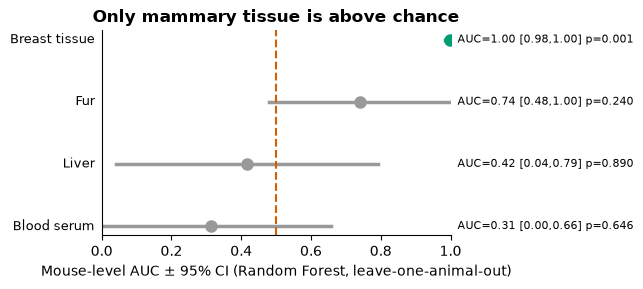

In [9]:
OI={'green':'#009E73','grey':'#999999','red':'#D55E00'}
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
pm=perm[perm.Model=='RandomForest'].set_index('Tissue')
fig,ax=plt.subplots(figsize=(6.6,3))
for i,t in enumerate(['Breast tissue','Fur','Liver','Blood serum'][::-1]):
    X,y,g,s=tissue(t); a=animal_scores(X,y,g,Pipeline([('p',SpectraPreproc(0.2)),('c',rf())]))
    pt,lo,hi=boot_ci(a); p=float(pm.loc[t,'perm_p']) if not pd.isna(pm.loc[t,'perm_p']) else np.nan
    col=OI['green'] if (p==p and p<0.05) else OI['grey']
    ax.plot([lo,hi],[i,i],color=col,lw=2.5); ax.plot(pt,i,'o',color=col,ms=8)
    ax.text(1.02,i,f"AUC={pt:.2f} [{lo:.2f},{hi:.2f}] p={p:.3f}",va='center',fontsize=8)
    ax.text(-0.02,i,t,ha='right',va='center',fontsize=9)
ax.axvline(0.5,color=OI['red'],ls='--'); ax.set_xlim(0,1); ax.set_yticks([])
ax.set_xlabel('Mouse-level AUC ± 95% CI (Random Forest, leave-one-animal-out)')
ax.set_title('Only mammary tissue is above chance',fontweight='bold'); plt.tight_layout(); plt.show()

## 8b. Preservation test — the correct endpoint (canonical)
Separate per-tissue classifiers test 'any cancer difference in this tissue', NOT 'is the mammary
signature preserved'. Here the breast-trained model is applied unchanged to each peripheral tissue.

In [10]:
pres = pd.read_csv('results/preservation_transfer.csv')
print(pres.to_string(index=False))
print("\nAll transfer AUCs <= 0.6 and n.s. -> the breast signature does NOT transfer to fur/liver/serum.")

       Model      Tissue  transfer_AUC  perm_p  perm_p_BH
      PLS-DA         Fur         0.460  0.7731      0.912
      PLS-DA       Liver         0.417  0.7236      0.912
      PLS-DA Blood serum         0.469  0.9120      0.912
RandomForest         Fur         0.185  0.0145      0.087
RandomForest       Liver         0.625  0.6167      0.912
RandomForest Blood serum         0.562  0.8156      0.912

All transfer AUCs <= 0.6 and n.s. -> the breast signature does NOT transfer to fur/liver/serum.


## 9. Conclusions
- **Mammary tumour signature is robust** (AUC ≈ 0.99 both models; permutation P = 0.002, BH 0.008; 98 mouse-level differential ions).
- **Fur** is weak and analysis-dependent — significant only for PLS-DA on per-animal means (raw P 0.006–0.026; BH ≈ 0.10), n.s. otherwise; does not exceed liver/serum. **Liver, serum** at chance; 0 peripheral differential ions.
- Original "fur preserves the tumour signature better than liver/serum" is **not supported**; peripheral findings are exploratory.
- Signature (spot-level): m/z 52, 53, 54, 66, 67, 80, 118 (157 excluded); animal-level core m/z 52, 53, 66.